# Phase 5: Benchmarking Missing-Value Imputation (MCAR vs MNAR)

This notebook benchmarks **missing-value imputation** performance under two missingness mechanisms:

1. **MCAR (Missing Completely At Random)**  
2. **MNAR (Missing Not At Random)**, where low-valued entries are preferentially masked

We compare:
- **MIMIR** (shared latent space model)
- **SoftImpute** (low-rank matrix completion)
- **KNN-Impute** (donor-based local imputation)

All evaluations are performed on the held-out test set using identical masks.


In [1]:
import pickle
from typing import Dict, Any, Optional, Tuple, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.data_utils import *
from src.mae_masked import *
from src.shared_finetune import *
from src.impute1 import *
from src.translation import *
from src.evaluation import *

In [3]:
with open('tcga_redo_mlomicZ.pkl', 'rb') as f:
    multi_omic_data = pickle.load(f)
    
print(multi_omic_data.keys())

common_samples, train_idx, val_idx, test_idx = load_shared_splits_from_json(
    multi_omic_data,
    json_path='splits.json'
)
print(f"Shared N={len(common_samples)} | train={len(train_idx)} | val={len(val_idx)}| test={len(test_idx)}")

dict_keys(['cnv', 'miRNA', 'rna', 'methylation'])
Shared N=8034 | train=6409 | val=798| test=800


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
train_loader, val_loader, test_loader = make_loaders_from_splits(
    multi_omic_data, common_samples, train_idx, val_idx, test_idx, batch_size=64
)
multi_ds = MultiOmicDataset({m: df for m, df in multi_omic_data.items()})
test_samples = [multi_ds.common_samples[i] for i in test_idx]
train_samples = [multi_ds.common_samples[i] for i in train_idx]
val_samples = [multi_ds.common_samples[i] for i in val_idx]

## Helper: loading stored imputation results

**MIMIR** imputation experiments are run in Notebook 5.
Here, we load:
- `mask_dfs`: boolean masks indicating which values were masked
- `pred_dfs`: imputed values
- `corrupt_dfs`: corrupted inputs (optional, used for some baselines)


In [5]:
def load_imputation_pickles(
    pred_pickle_path: str,
    mask_pickle_path: Optional[str] = None,
    corrupt_pickle_path: Optional[str] = None,
) -> Tuple[Dict[str, pd.DataFrame], Dict[str, pd.DataFrame], Optional[Dict[str, pd.DataFrame]]]:
    
    mask_dfs = None
    if mask_pickle_path is not None:
        with open(mask_pickle_path, "rb") as f:
            mask_dfs = pickle.load(f)

    
    with open(pred_pickle_path, "rb") as f:
        pred_dfs = pickle.load(f)

    corrupt_dfs = None
    if corrupt_pickle_path is not None:
        with open(corrupt_pickle_path, "rb") as f:
            corrupt_dfs = pickle.load(f)

    return mask_dfs, pred_dfs, corrupt_dfs

## 0.1 MIMIR missing-value imputation (MCAR)

We first evaluate MIMIR under MCAR missingness, where values are randomly masked
independently of their magnitude.

Metrics are computed **only on masked entries** to reflect true imputation accuracy.


In [6]:
mcar_mask_dfs, mcar_pred_dfs, mcar_corrupt_dfs = load_imputation_pickles(
    mask_pickle_path="missing_values_data/test_MCAR30_masks.pkl",
    pred_pickle_path="missing_values_data/test_MCAR30_preds.pkl",
    corrupt_pickle_path="missing_values_data/test_MCAR30_corrupt.pkl",
)

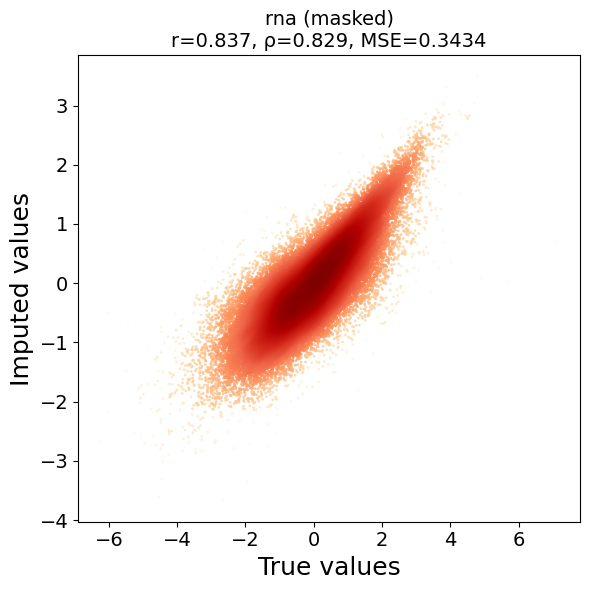

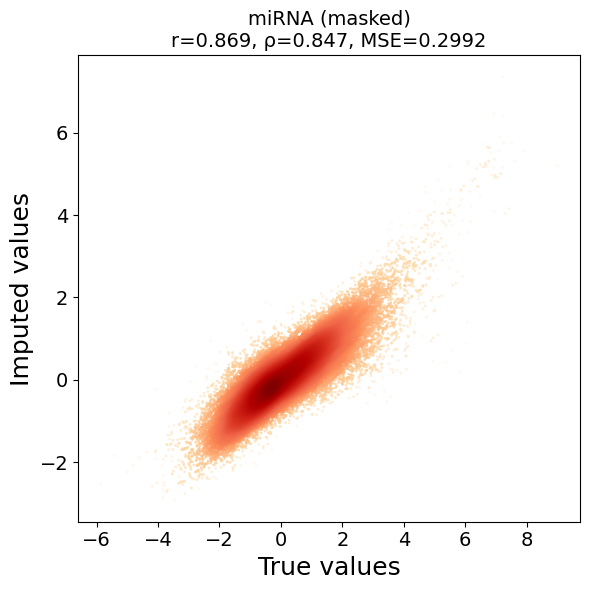

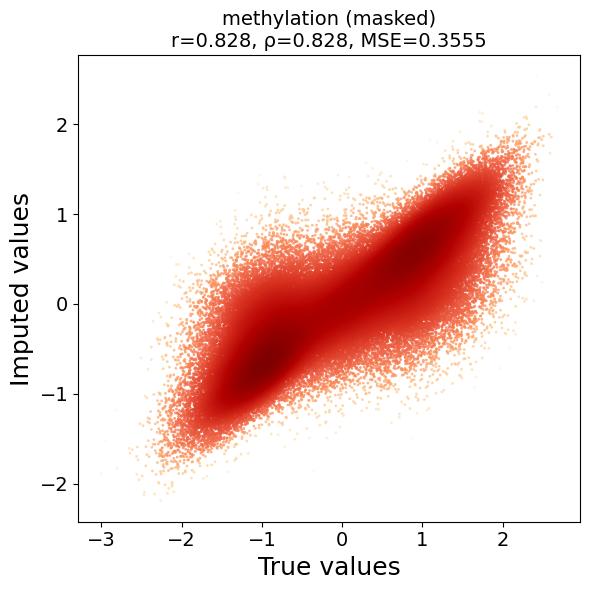

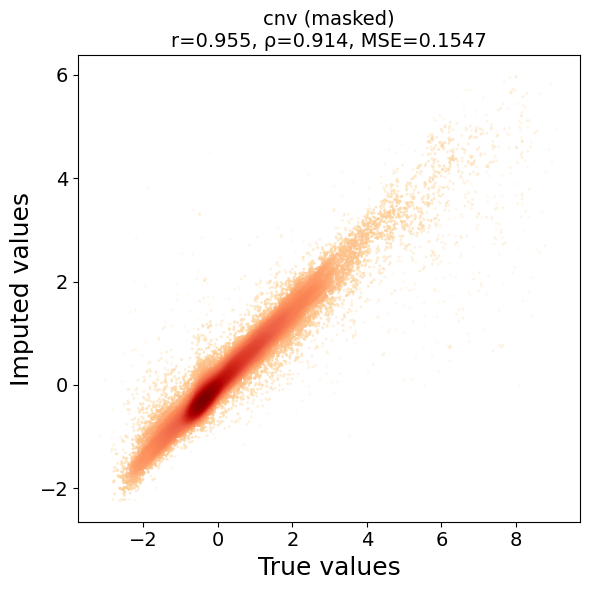

In [7]:
mimir_metrics_masked = evaluate_values_imputation(
    pred_dfs=mcar_pred_dfs,
    mask_dfs=mcar_mask_dfs,
    corrupt_dfs=mcar_corrupt_dfs,
    multi_omic_data=multi_omic_data,
    evaluate_on="masked",
    plot_scatter=True,
    max_points_plot=100000,
)

## 0.1.2 MIMIR missing-value imputation (MNAR)

We next evaluate MIMIR under MNAR missingness.
In this setting, lower-valued entries are preferentially masked, creating a systematic bias
that violates MCAR assumptions.


In [12]:
mnar_mask_dfs, mnar_pred_dfs, mnar_corrupt_dfs = load_imputation_pickles(
    mask_pickle_path="missing_values_data/test_MNAR30_masks.pkl",
    pred_pickle_path="missing_values_data/test_MNAR30_preds.pkl",
    corrupt_pickle_path="missing_values_data/test_MNAR30_corrupt.pkl",
)

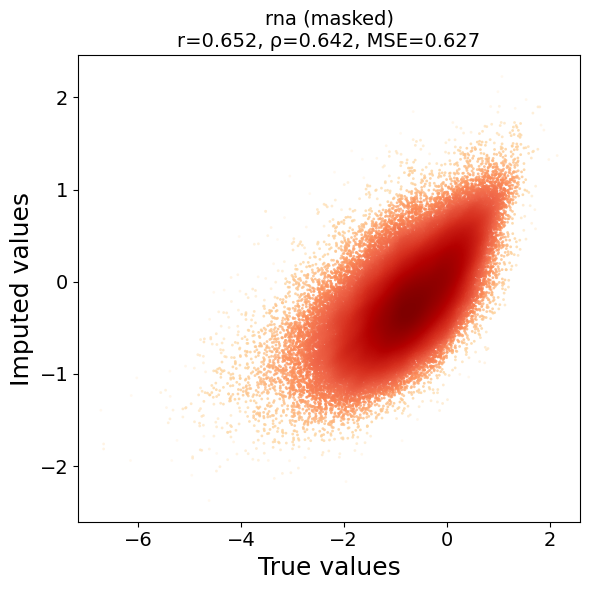

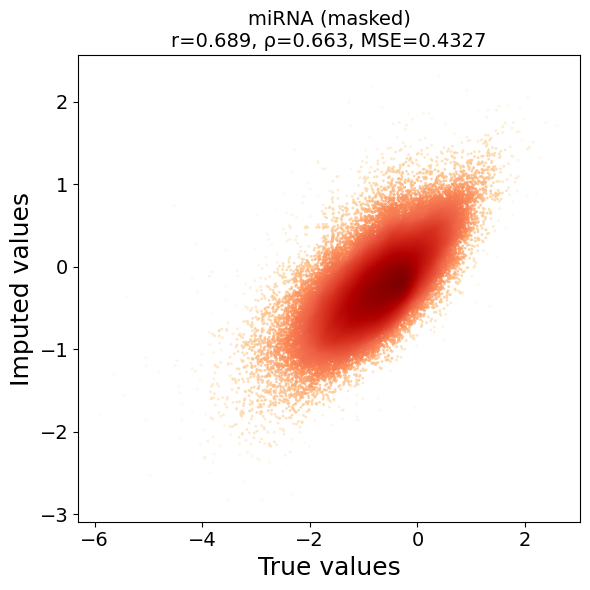

[WARN] No finite eval points for mod 'methylation' (evaluate_on=masked); skipping.
[WARN] No finite eval points for mod 'cnv' (evaluate_on=masked); skipping.


In [13]:
mnar_mimir_metrics_masked = evaluate_values_imputation(
    pred_dfs=mnar_pred_dfs,
    mask_dfs=mnar_mask_dfs,
    corrupt_dfs=mnar_corrupt_dfs,
    multi_omic_data=multi_omic_data,
    evaluate_on="masked",
    plot_scatter=True,
    max_points_plot=100000,
)

## 0.2 SoftImpute baseline

We benchmark SoftImpute, a low-rank matrix completion method.
Hyperparameters are tuned **only on the validation set under MCAR**, then fixed and reused
for test evaluation under both MCAR and MNAR.


In [8]:
# tune on VAL, then run once on TEST
from src.others.softimpv2 import impute_from_corrupt_soft_valtest

test_soft_pred_dfs, soft_info = impute_from_corrupt_soft_valtest(
    val_corrupt_pickle_path="missing_values_data/val_MCAR30_corrupt.pkl",
    test_corrupt_pickle_path="missing_values_data/test_MCAR30_corrupt.pkl",
    multi_omic_data=multi_omic_data,
    val_samples=val_samples,
    test_samples=test_samples,
    use_modalities=["rna", "miRNA", "methylation", "cnv"],
    J_grid=[64, 128, 256],                 # include 256 to compare with MIMIR
    lambda_grid=[0.0, 1.0, 3.0],
    maxit=100,
    thresh=1e-4,
    random_state=0,
    verbose=False,
    select_metric="rmse",                  # "rmse" (min), "mae" (min), or "pearson" (max)
    save_test_pred_pickle_path="missing_values_data/test_softMCAR_preds.pkl",
)

# inspect what was chosen
print("Best SoftImpute params:", soft_info["best_params"])
print("Best val score:", soft_info["best_val"]["overall"], "n=", soft_info["best_val"]["n_total"])


/net/noble/vol1/home/nambiar4/miniconda3/envs/mofa_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/net/noble/vol1/home/nambiar4/miniconda3/envs/mofa_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/net/noble/vol1/home/nambiar4/miniconda3/envs/mofa_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/net/noble/vol1/home/nambiar4/miniconda3/envs/mofa_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/net/noble/vol1/home/nambiar4/miniconda3/env

[Saved SoftImpute TEST predictions] missing_values_data/test_softMCAR_preds.pkl
Best SoftImpute params: {'J': 128, 'lambda_': 0.0, 'thresh': 0.0001, 'maxit': 100}
Best val score: 0.5539211688237239 n= 2305591


We select hyperparameters based on validation RMSE and apply the chosen configuration
once to the test set to avoid leakage.


In [10]:
_, soft_mcar_pred_dfs, _ = load_imputation_pickles(
    mask_pickle_path=None,
    pred_pickle_path="missing_values_data/test_softMCAR_preds.pkl",
    corrupt_pickle_path=None,  # optional but nice to have
)

mcar_soft_metrics_masked = evaluate_values_imputation(
    pred_dfs=soft_mcar_pred_dfs,
    mask_dfs=mcar_mask_dfs,
    corrupt_dfs=mcar_corrupt_dfs,
    multi_omic_data=multi_omic_data,
    evaluate_on="masked",
    plot_scatter=False,
)


In [11]:
mcar_soft_metrics_masked

{'rna': {'mse': 0.38803168728377707,
  'pearson': 0.7834142986951855,
  'spearman': 0.7716714907669641,
  'n_points': 721194},
 'miRNA': {'mse': 0.35601998545205954,
  'pearson': 0.7991914258407083,
  'spearman': 0.7639607556141134,
  'n_points': 91583},
 'methylation': {'mse': 0.4001612570906523,
  'pearson': 0.7769653696553465,
  'spearman': 0.7769193617782402,
  'n_points': 753052},
 'cnv': {'mse': 0.1358393658355223,
  'pearson': 0.9297432972795805,
  'spearman': 0.8818701259937528,
  'n_points': 745579}}

### SoftImpute under MNAR

For MNAR, we reuse the hyperparameters selected under MCAR to ensure a fair comparison.


In [14]:
from src.others.softimpv2 import impute_from_corrupt_soft
soft_pred_dfs, soft_info = impute_from_corrupt_soft(
    corrupt_pickle_path="missing_values_data/test_MNAR30_corrupt.pkl",
    multi_omic_data=multi_omic_data,
    samples=test_samples,
    use_modalities=["rna", "miRNA", "methylation", "cnv"],
    J=128,
    lambda_=0.0,
    thresh=1e-4,
    maxit=100,
    verbose=False,
    save_pred_pickle_path="missing_values_data/test_softMNAR_preds.pkl",
)


/net/noble/vol1/home/nambiar4/miniconda3/envs/mofa_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/net/noble/vol1/home/nambiar4/miniconda3/envs/mofa_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/net/noble/vol1/home/nambiar4/miniconda3/envs/mofa_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[Saved SoftImpute predictions] missing_values_data/test_softMNAR_preds.pkl


In [15]:
_, soft_mnar_pred_dfs, _ = load_imputation_pickles(
    mask_pickle_path=None,
    pred_pickle_path="missing_values_data/test_softMNAR_preds.pkl",
    corrupt_pickle_path=None,
)

soft_metrics_masked_MNAR = evaluate_values_imputation(
    pred_dfs=soft_mnar_pred_dfs,
    mask_dfs=mnar_mask_dfs,
    corrupt_dfs=mnar_corrupt_dfs,
    multi_omic_data=multi_omic_data,
    evaluate_on="masked",
    plot_scatter=False,
)


[WARN] No finite eval points for mod 'methylation' (evaluate_on=masked); skipping.
[WARN] No finite eval points for mod 'cnv' (evaluate_on=masked); skipping.


In [16]:
soft_metrics_masked_MNAR

{'rna': {'mse': 0.6072559905016323,
  'pearson': 0.5853487311573697,
  'spearman': 0.5706512714510711,
  'n_points': 721680},
 'miRNA': {'mse': 0.46393241797871176,
  'pearson': 0.5911045148678882,
  'spearman': 0.5661001649037884,
  'n_points': 91920}}

## 0.3 KNN-Impute baseline

We evaluate a KNN-based imputation method using donor samples from the training set.
The number of neighbors is set to √N_train, a common heuristic.


In [18]:
from src.others.knn_imp import *

In [30]:
np.sqrt(len(train_samples))

np.float64(80.05623023850174)

In [31]:
knn_pred_dfs = impute_values_from_corrupt(
    corrupt_pickle_path="missing_values_data/test_MCAR30_corrupt.pkl",
    multi_omic_data=multi_omic_data,
    train_samples=train_samples,
    use_modalities=["rna", "miRNA", "methylation",'cnv'],
    n_neighbors=80,
    weights="distance",
    save_pred_pickle_path="missing_values_data/test_knnMCAR_preds.pkl",
)


[Saved KNN predictions] missing_values_data/test_knnMCAR_preds.pkl


In [32]:
_, knn_mcar_pred_dfs, _ = load_imputation_pickles(
    mask_pickle_path=None,
    pred_pickle_path="missing_values_data/test_knnMCAR_preds.pkl",
    corrupt_pickle_path=None,
)

mcar_knn_metrics_masked = evaluate_values_imputation(
    pred_dfs=knn_mcar_pred_dfs,
    mask_dfs=mcar_mask_dfs,
    corrupt_dfs=mcar_corrupt_dfs,
    multi_omic_data=multi_omic_data,
    evaluate_on="masked",
    plot_scatter=False,
)


In [33]:
mcar_knn_metrics_masked

{'rna': {'mse': 0.431225331499312,
  'pearson': 0.7594853500473835,
  'spearman': 0.7432592086645761,
  'n_points': 721194},
 'miRNA': {'mse': 0.47052951126627074,
  'pearson': 0.7240971813039175,
  'spearman': 0.6876246304635214,
  'n_points': 91583},
 'methylation': {'mse': 0.45592866585817693,
  'pearson': 0.7440568483984933,
  'spearman': 0.7401568515693416,
  'n_points': 753052},
 'cnv': {'mse': 0.5246921805198104,
  'pearson': 0.7484242974136994,
  'spearman': 0.6948535349489586,
  'n_points': 745579}}

In [34]:
knn_pred_dfs = impute_values_from_corrupt(
    corrupt_pickle_path="missing_values_data/test_MNAR30_corrupt.pkl",
    multi_omic_data=multi_omic_data,
    train_samples=train_samples,
    use_modalities=["rna", "miRNA", "methylation",'cnv'],
    n_neighbors=80,
    weights="distance",
    save_pred_pickle_path="missing_values_data/test_knnMNAR_preds.pkl",
)


[Saved KNN predictions] missing_values_data/test_knnMNAR_preds.pkl


In [35]:
_, knn_mnar_pred_dfs, _ = load_imputation_pickles(
    mask_pickle_path=None,
    pred_pickle_path="missing_values_data/test_knnMNAR_preds.pkl",
    corrupt_pickle_path=None,
)

mnar_knn_metrics_masked = evaluate_values_imputation(
    pred_dfs=knn_mnar_pred_dfs,
    mask_dfs=mnar_mask_dfs,
    corrupt_dfs=mnar_corrupt_dfs,
    multi_omic_data=multi_omic_data,
    evaluate_on="masked",
    plot_scatter=False,
)


[WARN] No finite eval points for mod 'methylation' (evaluate_on=masked); skipping.
[WARN] No finite eval points for mod 'cnv' (evaluate_on=masked); skipping.


In [36]:
mnar_knn_metrics_masked

{'rna': {'mse': 0.6427392249728014,
  'pearson': 0.5589105648931153,
  'spearman': 0.5328656943682305,
  'n_points': 721680},
 'miRNA': {'mse': 0.44047449374730896,
  'pearson': 0.5597196959618667,
  'spearman': 0.5180185666795624,
  'n_points': 91920}}

## 0.4 Summary: method comparison


We summarize performance by comparing Pearson correlation for each target modality
across methods.


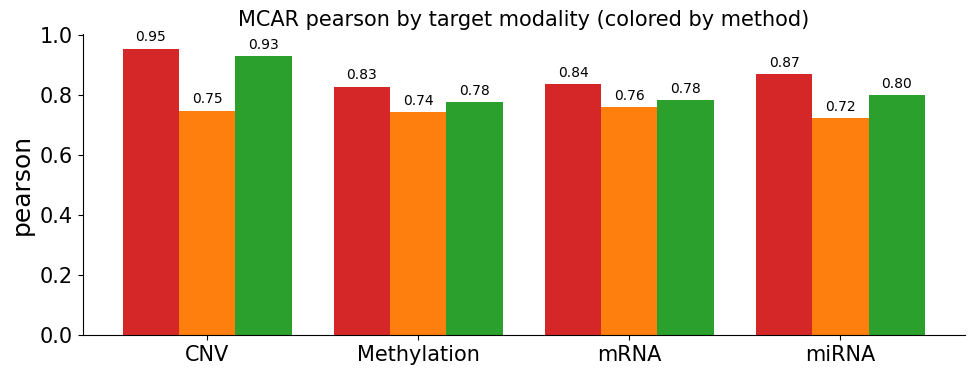

In [64]:
DISPLAY_NAME = {
    "rna": "mRNA",
    "miRNA": "miRNA",
    "cnv": "CNV",
    "methylation": "Methylation",
}
plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 18,
    "axes.titlesize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})

METHOD_COLORS = {
    "MIMIR": "tab:red",
    "KNN-Impute": "tab:orange",
    "SoftImpute": "tab:green",
}


def metrics_dict_to_df(metrics: dict, method_name: str) -> pd.DataFrame:
    rows = []
    present_mods = ("rna", "miRNA", "methylation",'cnv')
    for (target), d in metrics.items():
        rows.append({
            "method": method_name,
            "target": target,
            "target_display": DISPLAY_NAME.get(target, target),
            "present_mods": tuple(present_mods),
            "n_present": len(present_mods),
            "mse": d.get("mse"),
            "pearson": d.get("pearson"),
            "spearman": d.get("spearman"),
            "n_points": d.get("n_points"),
        })
    return pd.DataFrame(rows)

df = pd.concat([
    metrics_dict_to_df(mimir_metrics_masked, "MIMIR"),
    metrics_dict_to_df(mcar_knn_metrics_masked, "KNN-Impute"),
    metrics_dict_to_df(mcar_soft_metrics_masked, "SoftImpute"),
], ignore_index=True)


metric_key = "pearson"  # or "spearman" or "mse"

df_agg = (
    df.groupby(["method", "target", "target_display"], as_index=False)[metric_key]
      .max()
)


def grouped_barplot(df_agg, metric_key="pearson", method_order=None, target_order=None,title=None, legend=True):
    # Orders
    if method_order is None:
        method_order = list(df_agg["method"].unique())
    if target_order is None:
        target_order = list(df_agg.sort_values("target_display")["target_display"].unique())

    # Pivot to matrix: rows=targets, cols=methods
    mat = (
        df_agg.pivot(index="target_display", columns="method", values=metric_key)
             .reindex(index=target_order, columns=method_order)
    )

    x = np.arange(len(mat.index))
    n_methods = len(mat.columns)
    width = 0.8 / n_methods

    fig, ax = plt.subplots(figsize=(max(10, len(x)*1.3), 4))

    for i, method in enumerate(mat.columns):
        ax.bar(
            x + (i - (n_methods - 1) / 2) * width,
            mat[method].values,
            width=width,
            label=method,
            color=METHOD_COLORS.get(method, None),
        )

    ymax = mat.max().max()
    offset = 0.015 * ymax   # small vertical offset
    
    for i, method in enumerate(mat.columns):
        xs = x + (i - (n_methods - 1) / 2) * width
        ys = mat[method].values
    
        for xi, yi in zip(xs, ys):
            if np.isnan(yi):
                continue
            ax.text(
                xi,
                yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=10,
            )

    ymax = mat.max().max()
    #ax.set_ylim(0, ymax*1.32)

    ax.set_xticks(x)
    ax.set_xticklabels(mat.index, rotation=0)
    ax.set_ylabel(metric_key)
    ax.set_title(f"{title} {metric_key} by target modality (colored by method)")
    if legend:
            ax.legend(
        frameon=False,
        loc="center right",
        bbox_to_anchor=(-0.1, 0.5)
        )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

grouped_barplot(df_agg, metric_key=metric_key, method_order=["MIMIR","KNN-Impute","SoftImpute"],title='MCAR',legend=False)


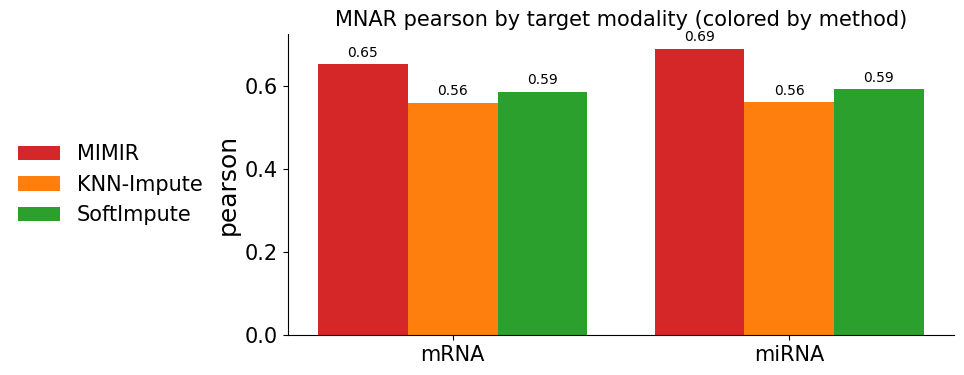

In [65]:
DISPLAY_NAME = {
    "rna": "mRNA",
    "miRNA": "miRNA",
    "cnv": "CNV",
    "methylation": "Methylation",
}
plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 18,
    "axes.titlesize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})

METHOD_COLORS = {
    "MIMIR": "tab:red",
    "KNN-Impute": "tab:orange",
    "SoftImpute": "tab:green",
}


df = pd.concat([
    metrics_dict_to_df(mnar_mimir_metrics_masked, "MIMIR"),
    metrics_dict_to_df(mnar_knn_metrics_masked, "KNN-Impute"),
    metrics_dict_to_df(soft_metrics_masked_MNAR, "SoftImpute"),
], ignore_index=True)


metric_key = "pearson"  # or "spearman" or "mse"

df_agg = (
    df.groupby(["method", "target", "target_display"], as_index=False)[metric_key]
      .max()
)


grouped_barplot(df_agg, metric_key=metric_key, method_order=["MIMIR","KNN-Impute","SoftImpute"],title='MNAR', legend=True)


## Understanding the MNAR setting

To illustrate how MNAR differs from MCAR, we compare the distribution of true values
at masked positions for each mechanism.


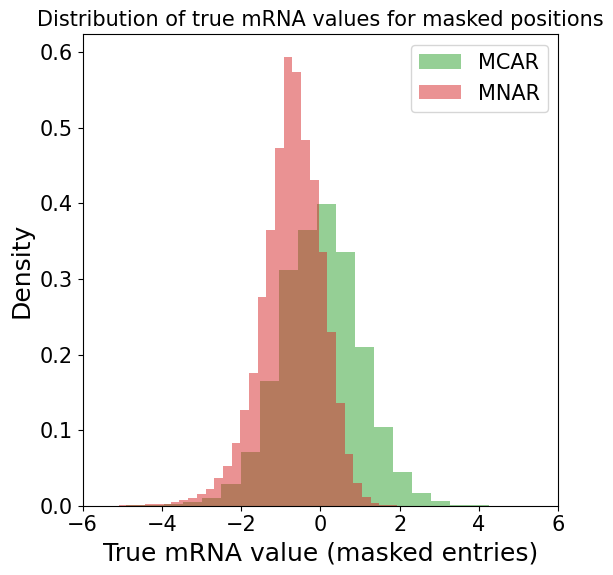

In [82]:
# Align
rna_true_mnar = multi_omic_data["rna"].loc[mnar_mask_dfs["rna"].index,
                                      mnar_mask_dfs["rna"].columns]
rna_mask_mnar = mnar_mask_dfs["rna"]

# Extract true values where mask is True
masked_true_vals_mnar = rna_true_mnar.values[rna_mask_mnar.values]

# Drop NaNs just in case
masked_true_vals_mnar = masked_true_vals_mnar[~np.isnan(masked_true_vals_mnar)]


# Align
rna_true_mcar = multi_omic_data["rna"].loc[mcar_mask_dfs["rna"].index,
                                      mcar_mask_dfs["rna"].columns]
rna_mask_mcar = mcar_mask_dfs["rna"]

# Extract true values where mask is True
masked_true_vals_mcar = rna_true_mcar.values[rna_mask_mcar.values]

# Drop NaNs just in case
masked_true_vals_mcar = masked_true_vals_mcar[~np.isnan(masked_true_vals_mcar)]

plt.figure(figsize=(6, 6))
plt.hist(masked_true_vals_mcar, bins=50, density=True, alpha=0.5,color='tab:green',label='MCAR')
plt.hist(masked_true_vals_mnar, bins=50, density=True, alpha=0.5, color='tab:red',label='MNAR')
plt.xlim(-6,6)
plt.xlabel("True mRNA value (masked entries)")
plt.ylabel("Density")
plt.title("Distribution of true mRNA values for masked positions")
plt.legend()
plt.tight_layout()
plt.show()

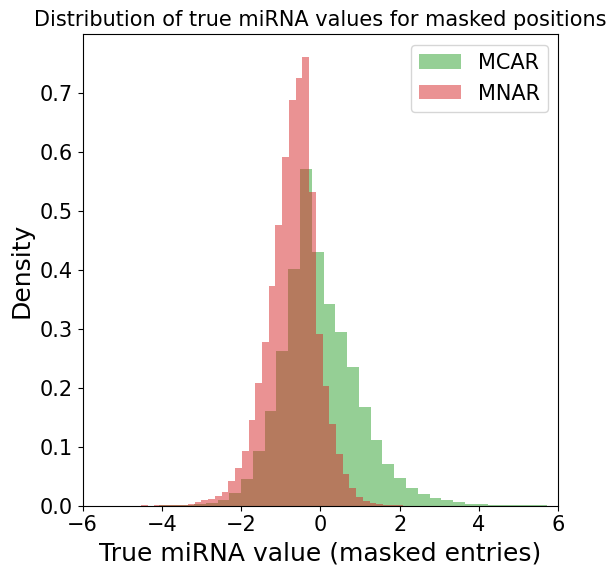

In [83]:
# Align
mirna_true_mnar = multi_omic_data["miRNA"].loc[mnar_mask_dfs["miRNA"].index,
                                      mnar_mask_dfs["miRNA"].columns]
mirna_mask_mnar = mnar_mask_dfs["miRNA"]

# Extract true values where mask is True
masked_true_vals_mnar = mirna_true_mnar.values[mirna_mask_mnar.values]

# Drop NaNs just in case
masked_true_vals_mnar = masked_true_vals_mnar[~np.isnan(masked_true_vals_mnar)]


# Align
mirna_true_mcar = multi_omic_data["miRNA"].loc[mcar_mask_dfs["miRNA"].index,
                                      mcar_mask_dfs["miRNA"].columns]
mirna_mask_mcar = mcar_mask_dfs["miRNA"]

# Extract true values where mask is True
masked_true_vals_mcar = mirna_true_mcar.values[mirna_mask_mcar.values]

# Drop NaNs just in case
masked_true_vals_mcar = masked_true_vals_mcar[~np.isnan(masked_true_vals_mcar)]

plt.figure(figsize=(6, 6))
plt.hist(masked_true_vals_mcar, bins=50, density=True, alpha=0.5,color='tab:green',label='MCAR')
plt.hist(masked_true_vals_mnar, bins=50, density=True, alpha=0.5, color='tab:red',label='MNAR')
plt.xlim(-6,6)
plt.xlabel("True miRNA value (masked entries)")
plt.ylabel("Density")
plt.title("Distribution of true miRNA values for masked positions")
plt.legend()
plt.tight_layout()
plt.show()